In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from model.parameters import *
from modules.transitory_functions import *

In [12]:
class plant:
    def __init__(self):

        self.state_name = ["C_O2_ccl"]
        self.gradient = {}
        for name in self.state_name:
            self.gradient["d" + name + " / dt"] = 0

        # Set points
        self.P_des = 1.5e5  # Pa
        self.T_des = 333.15  # K
        self.Phi_des = 0.5 # -
        self.Sc_des = 2.5  # -
        self.i_fc = 0.5e4  # A/m2
        # Variables
        self.t = 0
        self.Pccl = 0
        self.Pcgdl = 0
        self.C_N2 = self.P_des / (R * self.T_des) * 0.79  # mol/m3
        self.C_O2_cgc = 8.22  # mol/m3
        self.C_v_ccl = 0
        self.Tccl = 60 + 273.15  # K

    def dxdt(self, t, variables):

        self.dt = t - self.t
        self.t = t
       
        sv = {}
        for i_name in range(len(self.state_name)):
            sv[self.state_name[i_name]] = variables[i_name]

        # Massflow
        # Material properties
        epsilon_mean = epsilon_gdl / 2 + epsilon_cl / 2
        # Immediately calculation
        Psat = 101325 * 10 ** (-2.1794 + 0.02953 * (self.Tccl - 273.15) - 9.1837e-5 * (self.Tccl - 273.15) ** 2 +1.4454e-7 * (self.Tccl - 273.15) ** 3)
        self.Pcgdl = self.P_des
        self.C_v_ccl = self.Sc_des * Psat
        self.Pccl =  (self.C_v_ccl + sv["C_O2_ccl"] + self.C_N2) * R * self.Tccl

        s_ccl_cgdl = 0.02
        Pccl_cgdl = self.Pccl / 2 + self.Pcgdl / 2
        J_O2_ccl_cgdl = -  Dc_eff(s_ccl_cgdl, epsilon_mean, Pccl_cgdl, self.Tccl, epsilon_c, epsilon_gdl) * (self.C_O2_cgc - sv["C_O2_ccl"]) / (Hgdl + Hcl)

        # Mass flow of vapor at CGDL
        S_O2_ccl = - self.i_fc / (4 * F * Hcl)

        self.gradient['dC_O2_ccl / dt'] = 1 / (epsilon_cl * (1 - 0.02)) * (-J_O2_ccl_cgdl / Hcl + S_O2_ccl)

        return list(self.gradient.values())
    
    def getUcell(self, s_ccl, lambda_ccl, lambda_mem, C_O2_ccl):

        Re = 5.70e-7  # ohm.m². It is the electron conduction resistance of the circuit.
        i0_c_ref = 2.49  # A.m-2.It is the reference exchange current density at the cathode.
        kappa_c = 1.61  # It is the overpotential correction exponent.

        # The equilibrium potential
        Ueq = 1.18

        # The proton resistance
        # The proton resistance at the membrane : Rmem
        if lambda_mem >= 1:
            Rmem = Hmem / ((0.5139 * lambda_mem - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        else:
            Rmem = Hmem / (0.1879 * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        #  The proton resistance at the cathode catalyst layer : Rccl
        if lambda_ccl >= 1:
            Rccl = Hcl / ((epsilon_mc ** tau) * (0.5139 * lambda_ccl - 0.326) * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))
        else:
            Rccl = Hcl / ((epsilon_mc ** tau) * 0.1879 * np.exp(1268 * (1 / 303.15 - 1 / self.Tccl)))

        #  The total proton resistance
        Rp = Rmem + Rccl  # its value is around [4-7]e-6 ohm.m².
        slim = a_slim * (2e5 / 1e5) + b_slim
        s_switch = a_switch * slim
        f_drop = 0.5 * (1.0 - np.tanh((4 * s_ccl - 2 * slim - 2 * s_switch) / (slim - s_switch)))
        eta_c = 1 / f_drop * R * self.Tccl / (alpha_c * F) * np.log(self.i_fc / i0_c_ref * (C_O2ref / C_O2_ccl) ** kappa_c)
        # The cell voltage
        return Ueq - self.i_fc * (Rp + Re) - eta_c

    def Y(self, x):
        C_O2_ccl = x[0]
        self.Ucell = self.getUcell(s_ccl = 0.02, lambda_ccl = 8.5, lambda_mem = 8.2, C_O2_ccl = C_O2_ccl)
        return [self.Ucell]

In [13]:
class LuenbergerObserver:
    """First-order Luenberger observer for C_O2_ccl state estimation"""
    
    def __init__(self, plant, L: float, initial_state):
        """
        Initialize the Luenberger observer.
        
        Args:
            plant: Reference to the plant model
            L: Observer gain
            initial_state: Initial state estimate for C_O2_ccl
        """
        self.plant = plant
        self.L = L  # Observer gain
        self.x_new = initial_state
        self.x_hat = 1.0 # Estimated C_O2_ccl
        self.t_prev = 0
    
    def update(self, t, y_measured):
        """Update state estimate based on measured output"""
        dt = t - self.t_prev
        self.t_prev = t
        
        # RK4 integration for nonlinear dynamics prediction step
        k1 = self.plant.dxdt(t, [self.x_hat])[0]
        k2 = self.plant.dxdt(t + dt/2, [self.x_hat + dt/2 * k1])[0]
        k3 = self.plant.dxdt(t + dt/2, [self.x_hat + dt/2 * k2])[0]
        k4 = self.plant.dxdt(t + dt, [self.x_hat + dt * k3])[0]
        
        # RK4 weighted average
        self.x_new = self.x_hat + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        
        # Get predicted output from estimated state
        y_predicted = self.plant.Y([self.x_new])[0]
        
        # Observer correction term
        innovation = y_measured - y_predicted
        
        # Observer dynamics: Apply correction to predicted state
        self.x_hat = self.x_new + self.L * innovation
        
        return self.x_hat
    
    def reset(self, initial_state: float = 6.0):
        """Reset observer to initial state"""
        self.x_hat = initial_state
        self.t_prev = 0
    
    def get_estimate(self):
        """Get current state estimate"""
        return self.x_hat
    
    def set_gain(self, L: float):
        """Update observer gain"""
        self.L = L

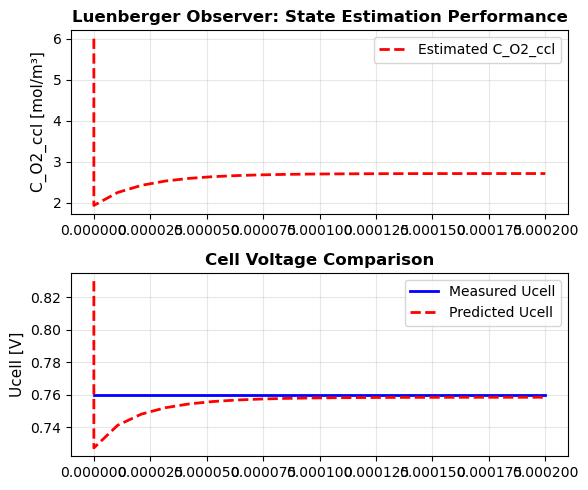

In [14]:
# Simulation parameters
t_sim = np.linspace(0, 0.0002, 20)  # 1 seconds simulation
dt = t_sim[1] - t_sim[0]

# Initialize plant and observer
plant = plant()
observer_gain = 1e1  # Tune this value for faster/slower convergence
LO = LuenbergerObserver(plant, L=observer_gain, initial_state=8.0)

# Storage for results
time_log = []
state_actual = []
state_estimated = []
output_measured = []
output_predicted = []
innovation_log = []
A_log = []

# Constant measured current density
plant.i_fc = 0.2e4  # A/m2

# Run simulation
x_actual = np.array([6.0])  # True initial state
time_log.append(0)
state_actual.append(x_actual[0])
state_estimated.append(x_actual[0])
output_measured.append( 0.76)
output_predicted.append( 0.83)
innovation_log.append(0.76 - 0.83)

O = [plant.Y([6.0])[0]/6.0]

for t in t_sim:
    # Get true system output (simulated measurement with small noise)
    y_measured = 0.76  # Measured output (can add noise here)
    
    # Update observer
    x = LO.x_hat
    x_hat = LO.update(t, y_measured)
    y_predicted = plant.Y([x_hat])[0]
    
    # Store data
    C = plant.Y([x_hat])[0]/x_actual[0]
    A = LO.x_new/x
    A_log.append(A)
    O_i = C
    for A_i in A_log:
        O_i *= A_i
    O.append(O_i)
    time_log.append(t)
    state_actual.append(x_actual[0])
    state_estimated.append(x_hat)
    output_measured.append(y_measured)
    output_predicted.append(y_predicted)
    innovation_log.append(y_measured - y_predicted)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(6, 5))

# Plot 1: State estimation
axes[0].plot(time_log, state_estimated, 'r--', linewidth=2, label='Estimated C_O2_ccl')
axes[0].set_ylabel('C_O2_ccl [mol/m³]', fontsize=11)
axes[0].set_title('Luenberger Observer: State Estimation Performance', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Output comparison
axes[1].plot(time_log, output_measured, 'b-', linewidth=2, label='Measured Ucell')
axes[1].plot(time_log, output_predicted, 'r--', linewidth=2, label='Predicted Ucell')
axes[1].set_ylabel('Ucell [V]', fontsize=11)
axes[1].set_title('Cell Voltage Comparison', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

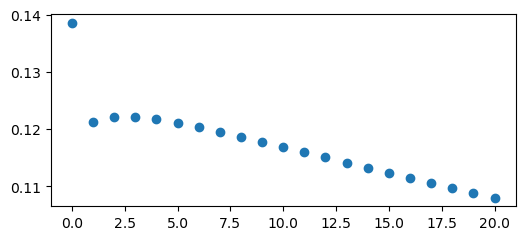

In [15]:
plt.figure(figsize=(6,2.5))
plt.scatter(range(len(O)), O)